In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import pickle
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score, accuracy_score, brier_score_loss, precision_recall_curve
from sklearn.model_selection import ParameterGrid
from expl_perf_drop.explainers import CGExplainerDR
from expl_perf_drop.utils import Graph
from tqdm.notebook import tqdm
tqdm.pandas()

print(datetime.datetime.now())


Initializing package . . . 😘
2025-03-17 14:37:56.062210


# Data processing

In [2]:
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

def agg_window_fast(window_df: pd.DataFrame):
    """
    window_df: columns=['offset','itemid','value']
    pivot -> shape=(#unique offset, #unique itemid)
    Then for each column(itemid), compute stats (mean, max, ...)
    """
    if window_df.empty:
        return {}

    pivoted = window_df.pivot(index='offset', columns='itemid', values='value')
    # pivoted: offset x itemid
    # col별 => mean, max, min, ...
    stats_dict = {}
    col_names = pivoted.columns
    means = pivoted.mean(axis=0)
    maxs  = pivoted.max(axis=0)
    mins  = pivoted.min(axis=0)
    stds  = pivoted.std(axis=0)
    meds  = pivoted.median(axis=0)
    q25s  = pivoted.quantile(0.25, axis=0)
    q75s  = pivoted.quantile(0.75, axis=0)
    counts = pivoted.count(axis=0)

    for item in col_names:
        # skip if all NaN?
        # or do if counts[item]==0 => skip
        rng = maxs[item] - mins[item] if counts[item]>0 else np.nan
        stats_dict[f'{item}_mean'] = means[item]
        stats_dict[f'{item}_max']  = maxs[item]
        stats_dict[f'{item}_min']  = mins[item]
        stats_dict[f'{item}_std']  = stds[item]
        stats_dict[f'{item}_median'] = meds[item]
        stats_dict[f'{item}_q25'] = q25s[item]
        stats_dict[f'{item}_q75'] = q75s[item]
        stats_dict[f'{item}_range'] = rng
        stats_dict[f'{item}_count'] = counts[item]

    return stats_dict


def get_clip_bounds_from_train(train_df: pd.DataFrame, binary_itemids: set, trim_percentile=0.01):
    """
    Train 데이터로부터 각 itemid별 (lower, upper) clip bound를 계산.
    binary_itemids는 trimming 제외.
    
    반환:
      clip_bounds: dict(itemid -> (lower, upper))
    """

    clip_bounds = {}
    for item_id, grp in train_df.groupby('itemid'):
        if item_id in binary_itemids:
            continue
        lower = grp['value'].quantile(trim_percentile)
        upper = grp['value'].quantile(1 - trim_percentile)
        clip_bounds[item_id] = (lower, upper)
    
    return clip_bounds

def apply_clip_bounds(df: pd.DataFrame, binary_itemids: set, clip_bounds: dict):
    """
    df를 itemid별로 나누어, clip_bounds가 있는 경우 그 범위 내로 trimming.
    binary itemid는 trimming 없이 그대로.
    """

    trimmed_parts = []
    for item_id, grp in df.groupby('itemid'):
        if item_id in binary_itemids:
            trimmed_parts.append(grp)
        else:
            if item_id in clip_bounds:
                l, u = clip_bounds[item_id]
                clipped = grp[(grp['value']>=l)&(grp['value']<=u)]
                trimmed_parts.append(clipped)
            else:
                trimmed_parts.append(grp)
    return pd.concat(trimmed_parts, ignore_index=True)


def aggregate_time_series_features_aki_stepwise(
    df: pd.DataFrame,
    outcome_df: pd.DataFrame,
    obs_window: int = 48*60,   # default 48시간
    step: int = 60,           # default 1시간 간격
    trim_percentile: float = 0.01
):
    """
    1) df ([hadm_id, offset, itemid, value])에 대해
       hadm_id별로 max_offset까지 step 간격으로 query_time을 생성.
       - window = [query_time, query_time + obs_window)
       - window 내 itemid별 통계를 계산( mean, max, min, etc... ).
    2) outcome_df ([hadm_id, aki_offset])를 이용해 aki 라벨링:
       - aki_offset이 window 안([wstart, wend]) 혹은 이전이면 => 해당 행 skip
       - aki_offset이 (wend, wend+480] 내에 있으면 => aki_label=1, else=0

    Returns:
      DataFrame: 각 (hadm_id, query_time) 별로 itemid 통계가 열이 되고,
                 aki_label 열이 추가됨.

    [주의] Trimming, 이진 변수 식별 등은 외부에서 해주세요.
    """

    # ------------------------
    # 0) Data 복사
    # ------------------------
    df_filtered = df.copy()

  
    # ------------------------
    # C) outcome_df -> dict {hadm_id: aki_offset}
    # ------------------------
    hadm2aki = outcome_df.set_index('hadm_id')['aki_offset'].to_dict()


    # ------------------------
    # E) hadm_id별로 step 윈도우 + aki 라벨링
    # ------------------------
    results = []

    hadm_groups = df_filtered.groupby('hadm_id')
    for hadm_id, group in tqdm(hadm_groups, desc="[aggregate aki stepwise]"):
        if group.empty:
            continue

        # aki_offset for this hadm
        aki_onsets = hadm2aki.get(hadm_id, [])
        max_offset = group['offset'].max()
        # step-based query_time
        start_qtime = obs_window
        end_qtime = max_offset - 480
        if end_qtime <= start_qtime:
            continue
        qtimes = range(obs_window, int(end_qtime)+1, step)

        for qtime in qtimes:
            win_start = qtime - obs_window
            win_end   = qtime 
            # 1) 윈도우 dataframe
            obs_window_df = group[(group['offset']>win_start) & (group['offset']<=win_end)].copy()
            if obs_window_df.empty or obs_window_df.shape[0]<10:
                continue

            # (A) 관찰 윈도우 내에 **어떤** AKI onset이 존재하면 sample skip
            if any((onset > win_start) and (onset <= win_end) for onset in aki_onsets):
                continue
            # (B) Query range 내에 AKI onset이 있으면 label=1, 없으면 0
            aki_label = 0
            if any((onset > win_end) and (onset <= win_end + 480) for onset in aki_onsets):
                aki_label = 1

            # 4) itemid별로 통계 계산
            row_dict = {
                'hadm_id': hadm_id,
                'query_time': qtime,
                'outcome': aki_label
            }

            stats_dict = agg_window_fast(obs_window_df[['offset','itemid','value']])
            row_dict.update(stats_dict)

            results.append(row_dict)

    # ------------------------
    # F) 결과 DataFrame
    # ------------------------
    final_df = pd.DataFrame(results)
    if final_df.empty:
        print("[aggregate_time_series_features_aki_stepwise] No data generated.")
        return final_df

    # 편의상 hadm_id, query_time, aki_label 순으로 정렬
    base_cols = ['hadm_id', 'query_time', 'outcome']
    other_cols = [c for c in final_df.columns if c not in base_cols]
    final_cols = base_cols + other_cols
    final_df = final_df[final_cols]

    return final_df

In [3]:
# Use Age, gender, height

mimic_static = pd.read_feather('mimic_data_static.feather')
# Gender is 1 for male, 0 for female
mimic_static['gender'] = (mimic_static['gender'] == 'M').astype(int)

# Change height to cm (*2.54)
mimic_static['height'] = mimic_static['height'] * 2.54


# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds_48_mimic.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

reverse_item_dict = {v: k for k, v in item_dict_total.items()}

# 새로운 dict를 생성하여, clip_bounds_all의 key를 원래 변수명으로 변경합니다.
clip_bounds = {}
for encoded_key, bounds in clip_bounds_all.items():
    original_name = reverse_item_dict.get(encoded_key, encoded_key)  # 매핑이 없으면 그대로 사용
    clip_bounds[original_name] = bounds

def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})

data = pd.concat([data_vital, data_lab, data_treatment])

# Factorize the 'item' column and get the mapping
encoded_total, actual_class_total = pd.factorize(data['itemid'])
# data.loc[:,'itemid'] = encoded_total.astype(int)
# data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

train_outcome_df = pd.read_feather('./model_results/train_aki_outcome.feather')
valid_outcome_df = pd.read_feather('./model_results/valid_aki_outcome.feather')
test_outcome_df = pd.read_feather('./model_results/test_aki_outcome.feather')

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(mimic_ids)

train_final_ids = train_outcome_df['hadm_id'].unique()
valid_final_ids = valid_outcome_df['hadm_id'].unique()
test_final_ids = test_outcome_df['hadm_id'].unique()

# (D) 최종 DF
train_df = data[data['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df)
train_binary_itemids = set()
for item_id, grp in train_df.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_trim = apply_clip_bounds(train_df, train_binary_itemids, clip_bounds)
valid_df_trim = apply_clip_bounds(valid_df, train_binary_itemids, clip_bounds)
test_df_trim  = apply_clip_bounds(test_df,  train_binary_itemids, clip_bounds)

train_df = aggregate_time_series_features_aki_stepwise(
    train_df_trim, train_outcome_df,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df = train_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df = aggregate_time_series_features_aki_stepwise(
    valid_df_trim, valid_outcome_df,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df = valid_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df = aggregate_time_series_features_aki_stepwise(
    test_df_trim, test_outcome_df,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df = test_df.merge(mimic_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

print(datetime.datetime.now())

21
[binary item ids] {'v', 'l', 'n', 'a_supplements', 'b', 'c01', 'ventilator', 'a_drug', 'c_else', 'm', 'r', 'h', 'antibiotics', 'a10', 'fluid'}


[aggregate aki stepwise]:   0%|          | 0/11930 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/3930 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/4056 [00:00<?, ?it/s]

2025-03-17 14:50:06.243052


In [4]:
# eICU
# embs_varwise
# Less samples because
# Use Age, gender, height

eicu_static = pd.read_feather('eicu_data_static.feather')

eicu_static = eicu_static.rename(columns={'admissionheight' : 'height', 'patientunitstayid' : 'hadm_id'})
# Gender is 1 for male, 0 for female
eicu_static['gender'] = (eicu_static['gender'] == 'Male').astype(int)


data_vital_eicu = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_lab_eicu = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})
data_treatment_eicu = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'})

data_eicu = pd.concat([data_vital_eicu, data_lab_eicu, data_treatment_eicu])

data_eicu = data_eicu.dropna(subset=['value'])
data_eicu_stats = calculate_all_stats(data_eicu)

item_dict_total = dict(zip(actual_class_total, range(len(actual_class_total))))
emb_idx_total = len(item_dict_total)

train_outcome_df_eicu = pd.read_feather('./model_results/train_aki_outcome_eicu.feather')
valid_outcome_df_eicu = pd.read_feather('./model_results/valid_aki_outcome_eicu.feather')
test_outcome_df_eicu = pd.read_feather('./model_results/test_aki_outcome_eicu.feather')

train_final_ids = train_outcome_df_eicu['hadm_id'].unique()
valid_final_ids = valid_outcome_df_eicu['hadm_id'].unique()
test_final_ids = test_outcome_df_eicu['hadm_id'].unique()

# (D) 최종 DF_eicu
train_df_eicu = data_eicu[data_eicu['hadm_id'].isin(train_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
valid_df_eicu = data_eicu[data_eicu['hadm_id'].isin(valid_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)
test_df_eicu = data_eicu[data_eicu['hadm_id'].isin(test_final_ids)].copy().sort_values(by=['hadm_id']).reset_index(drop=True)

# 1) 이진 변수는 'Train'에서 식별(또는 전체 df_eicu)
train_binary_itemids = set()
for item_id, grp in train_df_eicu.groupby('itemid'):
    uniq = set(grp['value'].dropna().unique())
    if uniq.issubset({0,1}):
        train_binary_itemids.add(item_id)
print("[binary item ids]", train_binary_itemids)


# 3) Train/Valid/Test 각각 trimming
train_df_eicu_trim = apply_clip_bounds(train_df_eicu, train_binary_itemids, clip_bounds)
valid_df_eicu_trim = apply_clip_bounds(valid_df_eicu, train_binary_itemids, clip_bounds)
test_df_eicu_trim  = apply_clip_bounds(test_df_eicu,  train_binary_itemids, clip_bounds)

train_df_eicu = aggregate_time_series_features_aki_stepwise(
    train_df_eicu_trim, train_outcome_df_eicu,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
train_df_eicu = train_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')

valid_df_eicu = aggregate_time_series_features_aki_stepwise(
    valid_df_eicu_trim, valid_outcome_df_eicu,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
valid_df_eicu = valid_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


test_df_eicu = aggregate_time_series_features_aki_stepwise(
    test_df_eicu_trim, test_outcome_df_eicu,
    obs_window=24*60,
    step=8*60,
    trim_percentile=0.01
).sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)
test_df_eicu = test_df_eicu.merge(eicu_static[['hadm_id', 'age', 'height', 'gender']], how='left', on='hadm_id')


valid_df_eicu = valid_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)
test_df_eicu  = test_df_eicu.reindex(columns=train_df_eicu.columns, fill_value=np.nan)

print(datetime.datetime.now())



[binary item ids] {'v', 'l', 'n', 'a_supplements', 'b', 'c01', 'ventilator', 'a_drug', 'c_else', 'm', 'r', 'h', 'antibiotic', 'a10', 'fluid'}


[aggregate aki stepwise]:   0%|          | 0/34479 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/8554 [00:00<?, ?it/s]

[aggregate aki stepwise]:   0%|          | 0/43033 [00:00<?, ?it/s]

2025-03-17 15:45:01.079647


In [5]:
save_directory = './stats_df/'

train_df.to_feather(f'{save_directory}train_aki_df.feather')
valid_df.to_feather(f'{save_directory}valid_aki_df.feather')

test_df.to_feather(f'{save_directory}test_aki_df.feather')

train_df_eicu.to_feather(f'{save_directory}train_aki_df_eicu.feather')
valid_df_eicu.to_feather(f'{save_directory}valid_aki_df_eicu.feather')
test_df_eicu.to_feather(f'{save_directory}test_aki_df_eicu.feather')


In [6]:
save_directory = './stats_df/'
train_df = pd.read_feather(f'{save_directory}train_aki_df.feather')
valid_df = pd.read_feather(f'{save_directory}valid_aki_df.feather')
test_df = pd.read_feather(f'{save_directory}test_aki_df.feather')

train_df_eicu = pd.read_feather(f'{save_directory}train_aki_df_eicu.feather')
valid_df_eicu = pd.read_feather(f'{save_directory}valid_aki_df_eicu.feather')
test_df_eicu = pd.read_feather(f'{save_directory}test_aki_df_eicu.feather')


In [7]:
train_emb_df = pd.read_csv('./model_results/train_embedding_mimic_24_fusion_aki48_8hr.csv')
valid_emb_df = pd.read_csv('./model_results/valid_embedding_mimic_24_fusion_aki48_8hr.csv')
test_emb_df = pd.read_csv('./model_results/test_embedding_mimic_24_fusion_aki48_8hr.csv')

train_emb_df = pd.merge(
    train_emb_df, 
    train_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

train_emb_df = train_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

train_emb_df = train_emb_df.drop(columns=['hadm_id','query_time'])


valid_emb_df = pd.merge(
    valid_emb_df, 
    valid_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

valid_emb_df = valid_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_emb_df = valid_emb_df.drop(columns=['hadm_id','query_time'])

test_emb_df = pd.merge(
    test_emb_df, 
    test_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

test_emb_df = test_emb_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_emb_df = test_emb_df.drop(columns=['hadm_id','query_time'])


In [8]:
# MIMIC
# embs_varwise
# Less samples because

train_vital_df = pd.read_csv('./model_results/train_embedding_mimic_vital_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df = pd.read_csv('./model_results/train_embedding_mimic_lab_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df = pd.read_csv('./model_results/train_embedding_mimic_treatment_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df = pd.merge(train_vital_df, train_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df = pd.merge(train_vars_df, train_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df = pd.read_csv('./model_results/valid_embedding_mimic_vital_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df = pd.read_csv('./model_results/valid_embedding_mimic_lab_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df = pd.read_csv('./model_results/valid_embedding_mimic_treatment_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df = pd.merge(valid_vital_df, valid_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df = pd.merge(valid_vars_df, valid_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df = pd.read_csv('./model_results/test_embedding_mimic_vital_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df = pd.read_csv('./model_results/test_embedding_mimic_lab_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df = pd.read_csv('./model_results/test_embedding_mimic_treatment_24_fusion_aki48_8hr.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df = pd.merge(test_vital_df, test_lab_df, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df = pd.merge(test_vars_df, test_treat_df, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df = pd.merge(
    train_vars_df, 
    train_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df에는 “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df = train_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df = train_vars_df.drop(columns=['hadm_id','query_time'])
train_df = train_df.drop(columns=['hadm_id','query_time'])


valid_vars_df = pd.merge(
    valid_vars_df, 
    valid_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df = valid_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df = valid_vars_df.drop(columns=['hadm_id','query_time'])
valid_df = valid_df.drop(columns=['hadm_id','query_time'])

test_vars_df = pd.merge(
    test_vars_df, 
    test_df[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df “train_df에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df = test_vars_df.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df = test_vars_df.drop(columns=['hadm_id','query_time'])
test_df = test_df.drop(columns=['hadm_id','query_time'])


In [9]:

train_vital_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_vital_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
train_lab_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_lab_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
train_treat_df_eicu = pd.read_csv('./model_results/train_embedding_eicu_treatment_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])

train_vars_df_eicu = pd.merge(train_vital_df_eicu, train_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
train_vars_df_eicu = pd.merge(train_vars_df_eicu, train_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

valid_vital_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_vital_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
valid_lab_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_lab_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
valid_treat_df_eicu = pd.read_csv('./model_results/valid_embedding_eicu_treatment_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])

valid_vars_df_eicu = pd.merge(valid_vital_df_eicu, valid_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
valid_vars_df_eicu = pd.merge(valid_vars_df_eicu, valid_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

test_vital_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_vital_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
test_lab_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_lab_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])
test_treat_df_eicu = pd.read_csv('./model_results/test_embedding_eicu_treatment_aki_inference_8.csv').sort_values(by=['hadm_id','query_time'])

test_vars_df_eicu = pd.merge(test_vital_df_eicu, test_lab_df_eicu, on=['hadm_id', 'query_time'], how='outer', suffixes=('_vital', '_lab'))
test_vars_df_eicu = pd.merge(test_vars_df_eicu, test_treat_df_eicu, on=['hadm_id', 'query_time'], how='outer').sort_values(by=['hadm_id', 'query_time']).reset_index(drop=True)

train_vars_df_eicu = pd.merge(
    train_vars_df_eicu, 
    train_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 train_vars_df_eicu에는 “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
train_vars_df_eicu = train_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
train_vars_df_eicu = train_vars_df_eicu.drop(columns=['hadm_id','query_time'])
train_df_eicu = train_df_eicu.drop(columns=['hadm_id','query_time'])


valid_vars_df_eicu = pd.merge(
    valid_vars_df_eicu, 
    valid_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 valid_vars_df_eicu “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
valid_vars_df_eicu = valid_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
valid_vars_df_eicu = valid_vars_df_eicu.drop(columns=['hadm_id','query_time'])
valid_df_eicu = valid_df_eicu.drop(columns=['hadm_id','query_time'])

test_vars_df_eicu = pd.merge(
    test_vars_df_eicu, 
    test_df_eicu[['hadm_id','query_time','outcome', 'age', 'height', 'gender']], 
    on=['hadm_id','query_time'], 
    how='inner'
)

# => 이제 test_vars_df_eicu “train_df_eicu에 존재하는 (hadm_id, query_time)만” 남음.
#    또한 'outcome' 열이 정확히 매칭된 상태로 합쳐짐.

# 4) 정렬 + reset_index
test_vars_df_eicu = test_vars_df_eicu.sort_values(by=['hadm_id','query_time']).reset_index(drop=True)

# 5) 만약 학습할 때 hadm_id, query_time 열은 필요 없으면 drop
#    (원하면 유지해도 됨)
test_vars_df_eicu = test_vars_df_eicu.drop(columns=['hadm_id','query_time'])
test_df_eicu = test_df_eicu.drop(columns=['hadm_id','query_time'])


# Representation modules

# Downstream modules

Input of the downstream modules for stay 'i' should be in form [rep1, rep2, ... , i_outcome]

In [10]:
valid_df = valid_df.reindex(columns=train_df.columns, fill_value=np.nan)
test_df  = test_df.reindex(columns=train_df.columns, fill_value=np.nan)

In [11]:

def grid_search_train_and_evaluate_downstream_model(train, 
                                                      valid,
                                                      test,
                                                      param_grid,
                                                      model_name='downstream_model',
                                                      save_path=None,
                                                      verbose=True):
    """
    grid search로 downstream 모델의 하이퍼파라미터를 탐색하여, 
    validation set의 AUPRC가 가장 높은 모델을 선택하고 test set 성능을 평가하는 함수.
    
    Parameters:
      - train, valid, test: 각 데이터셋은 'outcome' 열을 포함한 DataFrame.
          'outcome' 열은 타겟 레이블(예: 이진 변수)을 의미하며,
          나머지 컬럼들은 모델의 feature로 사용됩니다.
      - param_grid: 탐색할 하이퍼파라미터의 dictionary 
                    (예: {'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}).
      - model_name: 저장 시 모델 파일 이름에 사용할 이름 (기본값 'downstream_model')
      - save_path: 모델 저장 경로 (디렉토리 또는 파일 경로). None이면 저장하지 않음.
      - verbose: 학습 및 평가 결과 출력 여부
      
    Returns:
      - best_model: 선택된 XGBClassifier 모델.
      - best_params: best_model의 하이퍼파라미터 dict.
      - best_valid_auprc: validation set에서 측정한 AUPRC 값.
      - test_metrics: test set에 대한 평가 지표가 담긴 dict 
                      (AUROC, AUPRC, Precision, Recall, F1, Accuracy, Brier, Precision@Recall_0.8)
    """
    # 데이터 분리 (feature와 target)
    x_train = train.drop(columns=['outcome'])
    y_train = train['outcome']
    x_valid = valid.drop(columns=['outcome'])
    y_valid = valid['outcome']
    x_test = test.drop(columns=['outcome'])
    y_test = test['outcome']
    
    best_valid_auprc = -np.inf
    best_params = None
    best_model = None

    # grid search 수행: param_grid의 모든 조합에 대해 모델 학습 및 validation 평가
    for params in ParameterGrid(param_grid):
        if verbose:
            print("Trying parameters:", params)
        # 모델 초기화 (추가 파라미터 전달, GPU 사용)
        model = xgb.XGBClassifier(tree_method='hist', device='cuda', **params)
        model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=False)
        
        # validation set에 대한 예측 수행
        valid_y_pred_proba = model.predict_proba(x_valid)[:, 1]
        valid_auprc = average_precision_score(y_valid, valid_y_pred_proba)
        if verbose:
            print("Validation AUPRC: {:.4f}".format(valid_auprc))
        
        # 가장 좋은 AUPRC를 가진 모델 선택
        if valid_auprc > best_valid_auprc:
            best_valid_auprc = valid_auprc
            best_params = params
            best_model = model

    # best_model을 사용하여 test set 평가
    y_pred_proba = best_model.predict_proba(x_test)[:, 1]
    y_pred = best_model.predict(x_test)
    
    # 추가: Brier Score 계산
    brier = brier_score_loss(y_test, y_pred_proba)
    
    # 추가: 특정 recall 수준 (여기서는 0.8)에서의 precision 계산
    target_recall = 0.8
    precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
    # recall이 target_recall 이상인 구간에서의 최대 precision 선택
    if np.any(recalls >= target_recall):
        precision_at_target = np.max(precisions[recalls >= target_recall])
    else:
        precision_at_target = np.nan

    test_metrics = {
        'AUROC': roc_auc_score(y_test, y_pred_proba),
        'AUPRC': average_precision_score(y_test, y_pred_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Brier': brier,
        'Precision@Recall_0.8': precision_at_target
    }
    

    print("\nBest Hyperparameters:", best_params)
    print("Best Validation AUPRC: {:.4f}".format(best_valid_auprc))
    print("\nTest Metrics for the Best Model:")
    for key, value in test_metrics.items():
        print(f"{key}: {value:.4f}")

    # Precision-Recall Curve 그리기 (Test Data)
    plt.figure(figsize=(8,6))
    sns.lineplot(x=recalls, y=precisions, marker=',')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve ({model_name})')
    plt.xlim(0, 1)  # x축 범위 고정
    plt.ylim(0, 1)  # y축 범위 고정
    plt.grid(True)
    plt.show()


    # 모델 저장 (save_path가 제공된 경우)
    if save_path is not None:
        if os.path.isdir(save_path):
            file_path = os.path.join(save_path, f"{model_name}.pkl")
        else:
            file_path = save_path

        with open(file_path, 'wb') as f:
            pickle.dump(best_model, f)

        print(f"Model saved to {file_path}")

    return best_model, best_params, best_valid_auprc, test_metrics

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'scale_pos_weight' : [1, 10, 24]
}

var_categories = { 
    'static' : ['age', 'height', 'gender'],
    'lab': [f'emb_{i}_lab' for i in range(32)],
    'treat': [f'emb_{i}' for i in range(32)],
    'vital': [f'emb_{i}_vital' for i in range(32)],
    'outcome': ['outcome']
}


c:\Users\Jaewon\Documents\imvts_rep\.conda\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:45:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)



Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 10, 'subsample': 0.8}
Best Validation AUPRC: 0.3393

Test Metrics for the Best Model:
AUROC: 0.8052
AUPRC: 0.3549
Precision: 0.2163
Recall: 0.6387
F1: 0.3232
Accuracy: 0.8003
Brier: 0.1406
Precision@Recall_0.8: 0.1506


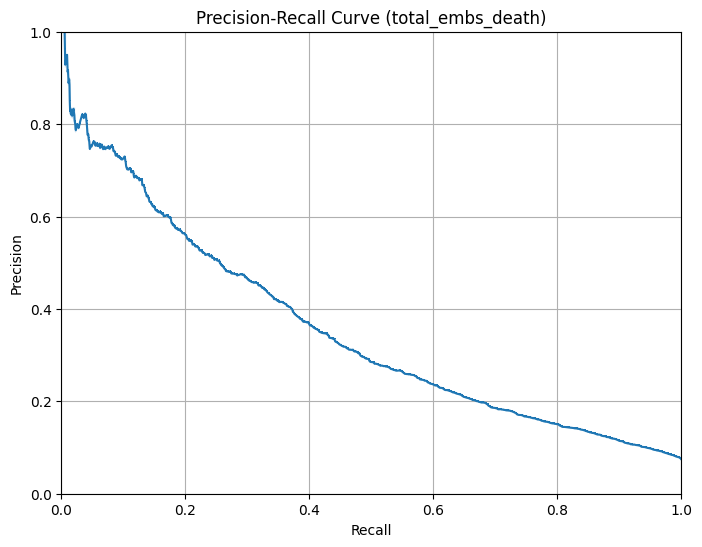

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.2684

Test Metrics for the Best Model:
AUROC: 0.7639
AUPRC: 0.2618
Precision: 0.5294
Recall: 0.0618
F1: 0.1106
Accuracy: 0.9259
Brier: 0.0621
Precision@Recall_0.8: 0.1268


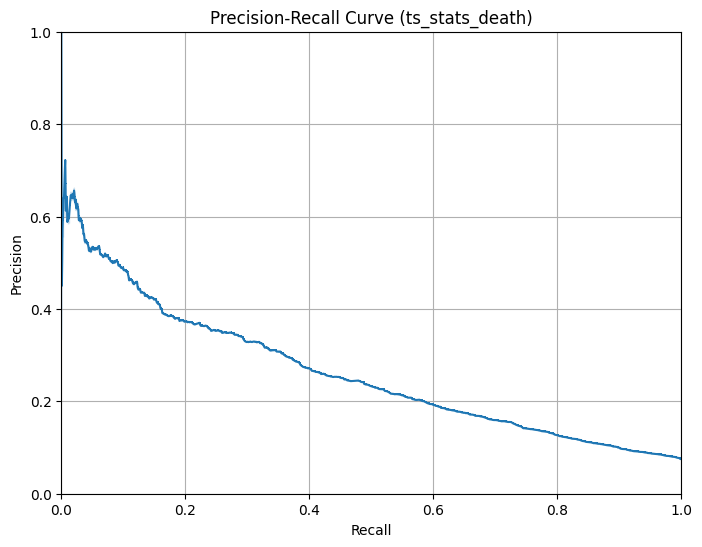

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.2906

Test Metrics for the Best Model:
AUROC: 0.7859
AUPRC: 0.2848
Precision: 0.5940
Recall: 0.0775
F1: 0.1370
Accuracy: 0.9272
Brier: 0.0610
Precision@Recall_0.8: 0.1394


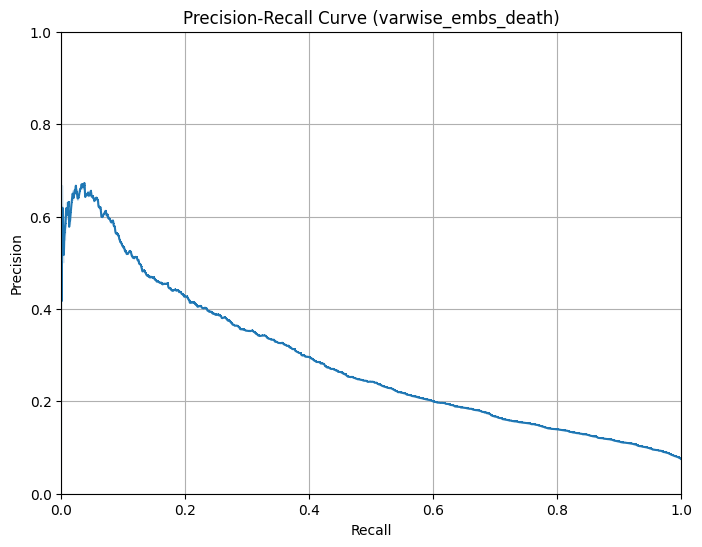

Model saved to ./saved_models

Comparison of Metrics:
Representation 1: {'AUROC': 0.8052053891909119, 'AUPRC': 0.3549498482139917, 'Precision': 0.21630146082337318, 'Recall': 0.6387254901960784, 'F1': 0.32316468253968256, 'Accuracy': 0.8002707944523731, 'Brier': 0.14060133746804798, 'Precision@Recall_0.8': 0.15057027225901398}
Representation 2: {'AUROC': 0.7639325945499996, 'AUPRC': 0.26181330861893765, 'Precision': 0.5294117647058824, 'Recall': 0.061764705882352944, 'F1': 0.1106233538191396, 'Accuracy': 0.9258635831381733, 'Brier': 0.062139230190733155, 'Precision@Recall_0.8': 0.12680652680652682}
Representation 3: {'AUROC': 0.7859343790901365, 'AUPRC': 0.28482273979338424, 'Precision': 0.5939849624060151, 'Recall': 0.07745098039215687, 'F1': 0.1370338248048569, 'Accuracy': 0.9271809133489461, 'Brier': 0.06103504468639676, 'Precision@Recall_0.8': 0.13942759504485264}


In [12]:
# Evaluate downstream model on REP_1
model_1, params_1, auprc_1, metrics_1 = grid_search_train_and_evaluate_downstream_model(
    train_emb_df,
    valid_emb_df,
    test_emb_df,
    param_grid,
    model_name='total_embs_death',
    save_path='./saved_models',
    verbose=False
)

# On REP_2 . . .
model_2, params_2, auprc_2, metrics_2 = grid_search_train_and_evaluate_downstream_model(
    train_df,
    valid_df,
    test_df,
    param_grid,
    model_name='ts_stats_death',
    save_path='./saved_models',
    verbose=False
)

model_3, params_3, auprc_3, metrics_3 = grid_search_train_and_evaluate_downstream_model(
    train_vars_df,
    valid_vars_df,
    test_vars_df,
    param_grid,
    model_name='varwise_embs_death',
    save_path='./saved_models',
    verbose=False
)

# Compare metrics...
print("\nComparison of Metrics:")
print("Representation 1:", metrics_1)
print("Representation 2:", metrics_2)
print("Representation 3:", metrics_3)

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

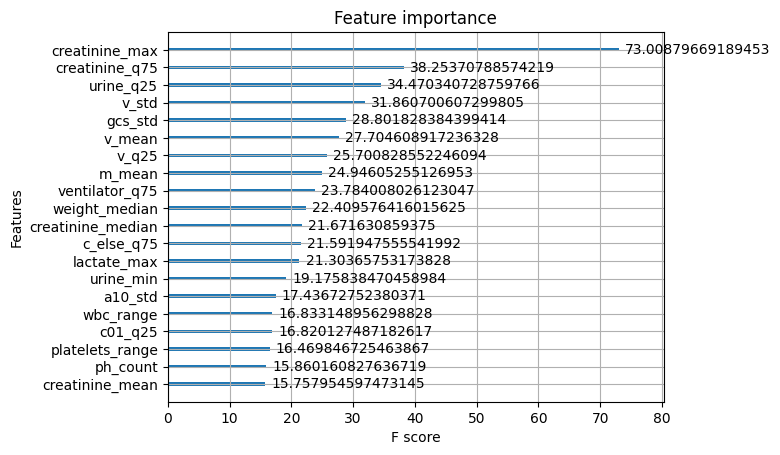

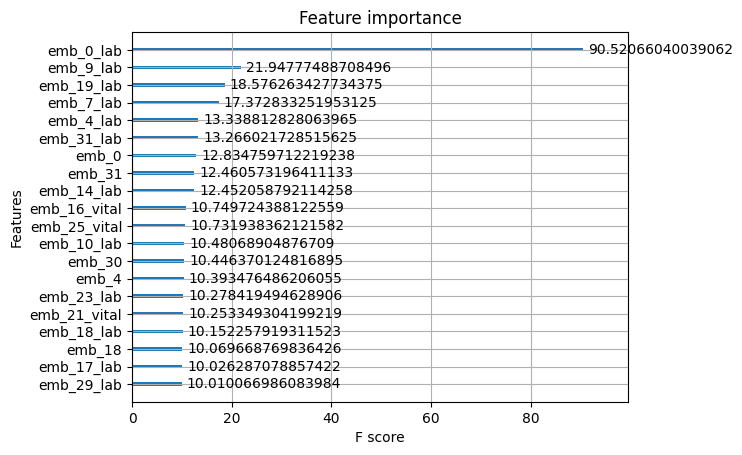

In [13]:
xgb.plot_importance(model_2.get_booster(), importance_type='gain', max_num_features=20)
xgb.plot_importance(model_3.get_booster(), importance_type='gain', max_num_features=20)


Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.2720

Test Metrics for the Best Model:
AUROC: 0.7837
AUPRC: 0.2703
Precision: 0.5638
Recall: 0.0520
F1: 0.0952
Accuracy: 0.9262
Brier: 0.0616
Precision@Recall_0.8: 0.1374


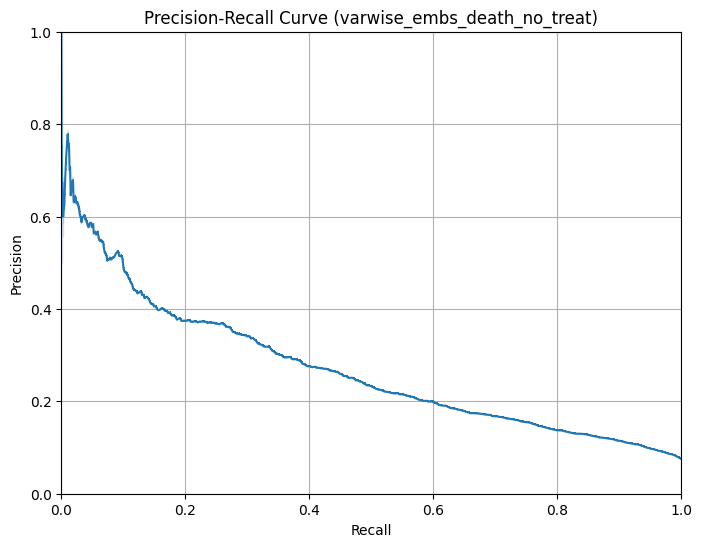

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.1781

Test Metrics for the Best Model:
AUROC: 0.6714
AUPRC: 0.1742
Precision: 0.5510
Recall: 0.0132
F1: 0.0258
Accuracy: 0.9255
Brier: 0.0662
Precision@Recall_0.8: 0.0958


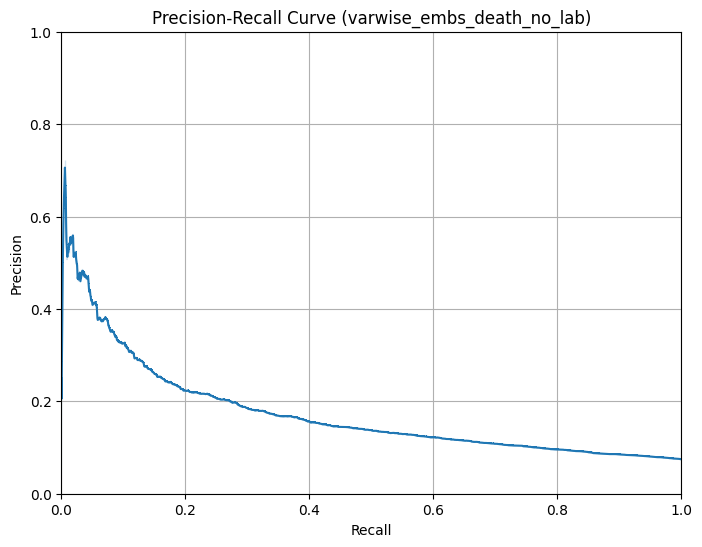

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 10, 'subsample': 0.8}
Best Validation AUPRC: 0.1354

Test Metrics for the Best Model:
AUROC: 0.6459
AUPRC: 0.1296
Precision: 0.1288
Recall: 0.4172
F1: 0.1968
Accuracy: 0.7458
Brier: 0.1892
Precision@Recall_0.8: 0.0936


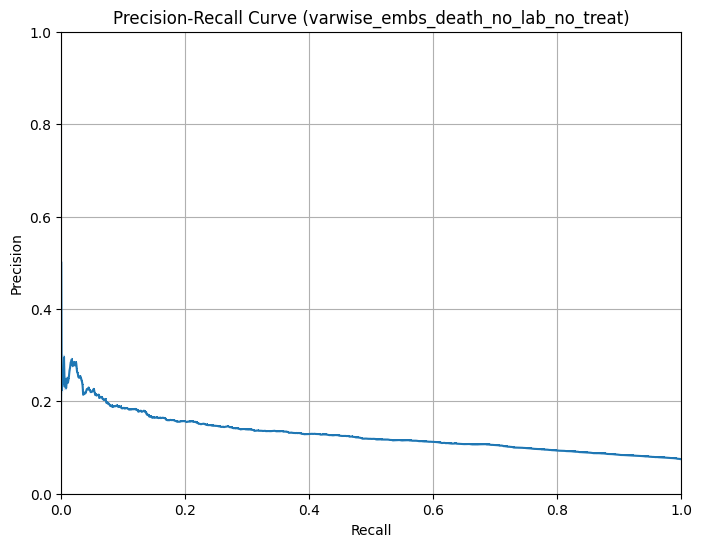

Model saved to ./saved_models

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Best Validation AUPRC: 0.2780

Test Metrics for the Best Model:
AUROC: 0.7819
AUPRC: 0.2906
Precision: 0.6162
Recall: 0.0598
F1: 0.1090
Accuracy: 0.9270
Brier: 0.0609
Precision@Recall_0.8: 0.1326


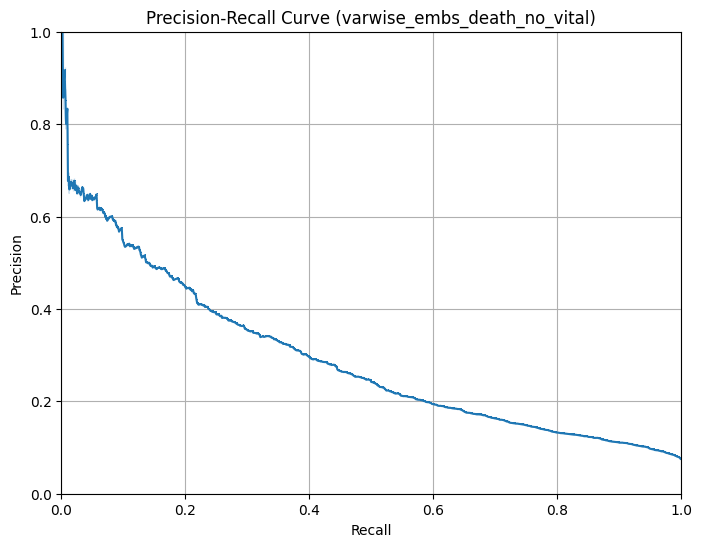

Model saved to ./saved_models
=== Version 4 (no treat) ===
{'AUROC': 0.7836509489116747, 'AUPRC': 0.27029181371441924, 'Precision': 0.5638297872340425, 'Recall': 0.05196078431372549, 'F1': 0.09515260323159784, 'Accuracy': 0.9262295081967213, 'Brier': 0.06162512741748283, 'Precision@Recall_0.8': 0.13744634290042926}
=== Version 5 (no lab) ===
{'AUROC': 0.6714193374676666, 'AUPRC': 0.17418169461281857, 'Precision': 0.5510204081632653, 'Recall': 0.013235294117647059, 'F1': 0.02584968884633796, 'Accuracy': 0.9255342505854801, 'Brier': 0.0661931494833171, 'Precision@Recall_0.8': 0.09579960107943213}
=== Version 6 (no lab & no treat) ===
{'AUROC': 0.6459017122745967, 'AUPRC': 0.12956977272974873, 'Precision': 0.12876380692994402, 'Recall': 0.41715686274509806, 'F1': 0.1967857555786796, 'Accuracy': 0.7457918618266979, 'Brier': 0.1891561249384041, 'Precision@Recall_0.8': 0.09355854566275408}
=== Version 7 (no vital) ===
{'AUROC': 0.7819198519331807, 'AUPRC': 0.2905795361588249, 'Precision': 0.

In [14]:
# Version 4: treat 변수 제외
train_vars_no_treat = train_vars_df.drop(columns=var_categories['treat'])
valid_vars_no_treat = valid_vars_df.drop(columns=var_categories['treat'])
test_vars_no_treat  = test_vars_df.drop(columns=var_categories['treat'])

model_v4, params_v4, auprc_v4, metrics_v4 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_treat,
    valid_vars_no_treat,
    test_vars_no_treat,
    param_grid,
    model_name='varwise_embs_death_no_treat',
    save_path='./saved_models',
    verbose=False
)

# Version 5: lab 변수 제외
train_vars_no_lab = train_vars_df.drop(columns=var_categories['lab'])
valid_vars_no_lab = valid_vars_df.drop(columns=var_categories['lab'])
test_vars_no_lab  = test_vars_df.drop(columns=var_categories['lab'])

model_v5, params_v5, auprc_v5, metrics_v5 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_lab,
    valid_vars_no_lab,
    test_vars_no_lab,
    param_grid,
    model_name='varwise_embs_death_no_lab',
    save_path='./saved_models',
    verbose=False
)

# Version 6: lab와 treat 모두 제외
cols_to_drop = var_categories['lab'] + var_categories['treat']
train_vars_no_lt = train_vars_df.drop(columns=cols_to_drop)
valid_vars_no_lt = valid_vars_df.drop(columns=cols_to_drop)
test_vars_no_lt  = test_vars_df.drop(columns=cols_to_drop)

model_v6, params_v6, auprc_v6, metrics_v6 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_lt,
    valid_vars_no_lt,
    test_vars_no_lt,
    param_grid,
    model_name='varwise_embs_death_no_lab_no_treat',
    save_path='./saved_models',
    verbose=False
)

# Version 7: vital 제외
cols_to_drop = var_categories['vital']
train_vars_no_vital = train_vars_df.drop(columns=cols_to_drop)
valid_vars_no_vital = valid_vars_df.drop(columns=cols_to_drop)
test_vars_no_vital  = test_vars_df.drop(columns=cols_to_drop)

model_v7, params_v7, auprc_v7, metrics_v7 = grid_search_train_and_evaluate_downstream_model(
    train_vars_no_vital,
    valid_vars_no_vital,
    test_vars_no_vital,
    param_grid,
    model_name='varwise_embs_death_no_vital',
    save_path='./saved_models',
    verbose=False
)

# 결과 출력 (예시)
print("=== Version 4 (no treat) ===")
print(metrics_v4)
print("=== Version 5 (no lab) ===")
print(metrics_v5)
print("=== Version 6 (no lab & no treat) ===")
print(metrics_v6)
print("=== Version 7 (no vital) ===")
print(metrics_v7)


Test Metrics for model_3:
AUROC: 0.7196
AUPRC: 0.1473
Precision: 0.3116
Recall: 0.0288
F1: 0.0527
Accuracy: 0.9362
Brier: 0.0573
Precision@Recall_0.8: 0.0955


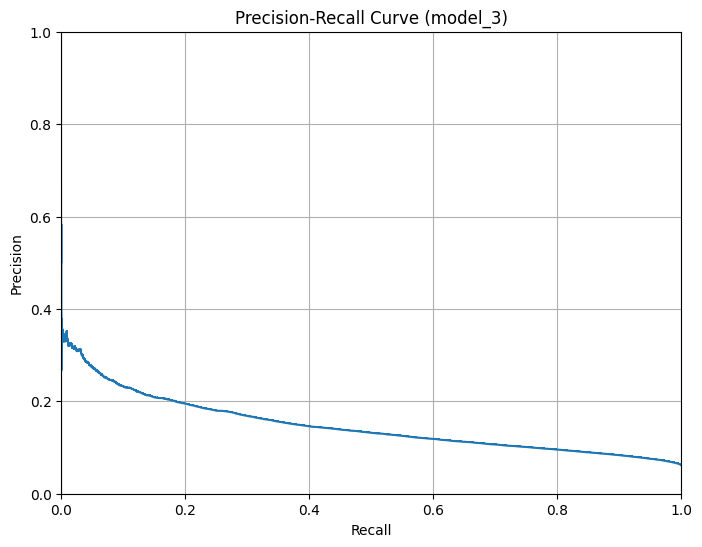

In [15]:
# test_vars_df_eicu의 'outcome' 열은 label, 나머지는 feature로 사용
X_test = test_vars_df_eicu.drop(columns=['outcome'])
y_test = test_vars_df_eicu['outcome']

# model_3로 예측 수행 (model_3는 sklearn wrapper를 사용하는 XGB 모델)
y_pred_proba = model_3.predict_proba(X_test)[:, 1]
y_pred = model_3.predict(X_test)

# 평가 지표 계산
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
accuracy_val = accuracy_score(y_test, y_pred)
brier = brier_score_loss(y_test, y_pred_proba)

# 특정 recall (0.8) 이상인 구간에서의 최대 precision 계산
target_recall = 0.8
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
if np.any(recalls >= target_recall):
    precision_at_target = np.max(precisions[recalls >= target_recall])
else:
    precision_at_target = np.nan

test_metrics = {
    'AUROC': auroc,
    'AUPRC': auprc,
    'Precision': precision_val,
    'Recall': recall_val,
    'F1': f1_val,
    'Accuracy': accuracy_val,
    'Brier': brier,
    'Precision@Recall_0.8': precision_at_target
}

print("\nTest Metrics for model_3:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Precision-Recall Curve 그리기 (x, y축 범위를 0~1로 고정)
plt.figure(figsize=(8,6))
sns.lineplot(x=recalls, y=precisions, marker=',')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (model_3)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Explain

In [16]:

# define the causal graph
GRAPH = Graph(
    nodes= list(var_categories.keys()),
    edges=[
        ('static', 'vital'),
        ('static', 'lab'),
        ('vital', 'treat'),
        ('lab', 'treat'),
        ('static', 'treat'),
        ('static', 'outcome'),
        ('vital', 'outcome'), 
        ('lab', 'outcome'), 
        ('treat', 'outcome'), 
    ]
)

train_features = var_categories['static'] + var_categories['lab'] + var_categories['treat'] + var_categories['vital']


In [17]:
def auprc(model, data, subset_cols=None, weight=None, target_name='outcome'):
    """
    모델의 예측 확률을 사용해 AUPRC (Average Precision Score)를 계산하는 함수.

    Parameters:
      - model: 예측 모델 (predict_proba 메서드가 있어야 함)
      - data: 평가할 DataFrame
      - subset_cols: 사용할 feature 컬럼 리스트 (None이면 전체 데이터 사용)
      - weight: 샘플 가중치 (None이면 가중치 없이 계산)
      - target_name: 타겟 컬럼 이름 (기본값 'Y')

    Returns:
      - AUPRC 값 (float)
    """
    data_input = data[subset_cols] if subset_cols is not None else data
    return average_precision_score(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight=weight)

def brier(model, data, subset_cols = None, weight = None, target_name = 'outcome'):
    data_input = data[subset_cols] if subset_cols is not None else data
    return brier_score_loss(data[target_name], model.predict_proba(data_input)[:, 1], sample_weight = weight)

In [18]:
train_features = ['emb_0_vital', 'emb_1_vital', 'emb_2_vital', 'emb_3_vital', 'emb_4_vital', 'emb_5_vital',
                'emb_6_vital', 'emb_7_vital', 'emb_8_vital', 'emb_9_vital', 'emb_10_vital', 'emb_11_vital',
                'emb_12_vital', 'emb_13_vital', 'emb_14_vital', 'emb_15_vital', 'emb_16_vital', 'emb_17_vital',
                'emb_18_vital', 'emb_19_vital', 'emb_20_vital', 'emb_21_vital', 'emb_22_vital', 'emb_23_vital',
                'emb_24_vital', 'emb_25_vital', 'emb_26_vital', 'emb_27_vital', 'emb_28_vital', 'emb_29_vital',
                'emb_30_vital', 'emb_31_vital', 'emb_0_lab', 'emb_1_lab', 'emb_2_lab', 'emb_3_lab', 'emb_4_lab',
                'emb_5_lab', 'emb_6_lab', 'emb_7_lab', 'emb_8_lab', 'emb_9_lab', 'emb_10_lab', 'emb_11_lab', 
                'emb_12_lab', 'emb_13_lab', 'emb_14_lab', 'emb_15_lab', 'emb_16_lab', 'emb_17_lab', 'emb_18_lab', 
                'emb_19_lab', 'emb_20_lab', 'emb_21_lab', 'emb_22_lab', 'emb_23_lab', 'emb_24_lab', 'emb_25_lab', 
                'emb_26_lab', 'emb_27_lab', 'emb_28_lab', 'emb_29_lab', 'emb_30_lab', 'emb_31_lab', 'emb_0', 'emb_1', 
                'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 
                'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 
                'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'age', 'height', 'gender']

In [19]:
exp = CGExplainerDR(GRAPH, train_vars_df, test_vars_df, train_vars_df_eicu, valid_vars_df_eicu,
        train_features, var_categories, target_name = 'outcome'
)

In [20]:
perfs = exp.get_perf_on_sets(model_3, metric = auprc)
perfs

{'source': 0.28482273979338424, 'target': 0.1515499037796001}

In [21]:
exp.get_all_possible_shifts()


['static',
 (frozenset({'static'}), 'lab'),
 (frozenset({'lab', 'static', 'vital'}), 'treat'),
 (frozenset({'static'}), 'vital'),
 (frozenset({'lab', 'static', 'treat', 'vital'}), 'outcome')]

In [22]:
res_auprc = exp.explain(model_3, metric = auprc)
res_auprc

Evaluate set function: 32it [00:11,  2.91it/s]


P(static)                             -0.025948
P(lab | static)                       -0.035372
P(treat | lab,static,vital)            0.046291
P(vital | static)                     -0.181609
P(outcome | lab,static,treat,vital)   -0.026129
dtype: float64

In [23]:
exp.scale(res_auprc, perfs)

P(static)                             -0.015524
P(lab | static)                       -0.021162
P(treat | lab,static,vital)            0.027694
P(vital | static)                     -0.108649
P(outcome | lab,static,treat,vital)   -0.015632
dtype: float64

In [24]:
perfs = exp.get_perf_on_sets(model_3, metric = brier)
perfs

{'source': 0.06103504468639676, 'target': 0.056708355383761344}

In [25]:
res_brier = exp.explain(model_3, metric = brier)
res_brier

Evaluate set function: 32it [00:00, 81.24it/s]


P(static)                             -0.008345
P(lab | static)                       -0.029520
P(treat | lab,static,vital)            0.027861
P(vital | static)                     -0.012908
P(outcome | lab,static,treat,vital)   -0.001941
dtype: float64

In [26]:
exp.scale(res_brier, perfs)

P(static)                             -0.001453
P(lab | static)                       -0.005139
P(treat | lab,static,vital)            0.004850
P(vital | static)                     -0.002247
P(outcome | lab,static,treat,vital)   -0.000338
dtype: float64